
# MLP Laboratory — Part 1: Forward/Backward, Mini-batch, L2, and Dropout

**Objetivo.** Este cuaderno permite **reproducir** y **estudiar** experimentalmente los conceptos de tu teoría
(forward/backward, regularización y descenso por gradiente) usando tu MLP vectorizado (tanh/σ), con:
- Inicializaciones: **Xavier** (tanh) y **He** (ReLU).
- **Pérdida MSE** (cuadrática) binaria (alineada con la notación de la sección teórica).
- **Regularización L2** opcional con divisor global \(m_\text{train}\).
- **Dropout invertido** opcional por capa (en entrenamiento).
- **Mini-batch** opcional con *shuffling* por época.
- **Métricas**: coste por época y accuracy train/test.
- **Visualizaciones**: curvas de entrenamiento y frontera de decisión.

**Qué vamos a ver y qué se espera** (hipótesis empíricas a contrastar):
1. *Mini-batch vs Full-batch*: los batches pequeños inducen más ruido en el coste pero pueden converger más rápido por unidad de cómputo; accuracy similar si no hay regularización.
2. *L2 (weight decay)*: reduce \(\|W\|\), acorta el gap train–test y puede sacrificar algo de accuracy si es excesivo.
3. *Dropout*: mejora generalización al romper co-adaptaciones, con convergencia algo más lenta; p bajo ⇒ posible *underfit*.
4. *L2 vs Dropout vs Ambos*: efectos complementarios; combinar suele estabilizar sin excesiva pérdida de capacidad.
5. *Fronteras de decisión*: los regularizadores suavizan la frontera y reducen oscilaciones locales.

> **Nota:** Este cuaderno usa la notación de tu teoría: \(Z^{[l]}=W^{[l]}A^{[l-1]}+b^{[l]}\), \(A^{[l]}=g^{[l]}(Z^{[l]})\), con \(A^{[0]}=X\).


In [2]:

from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Dict, Tuple, List, Mapping, Optional, Any

import numpy as np
from numpy.typing import NDArray
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

Array = NDArray[np.float64]
Activation = Callable[[Array], Array]
ActivationPrime = Callable[[Array], Array]

def plot_history(history, title_prefix: str = ""):
    # Simple training curves: cost and accuracy (train/test).
    # One figure per metric (no subplots). No explicit colors.
    plt.figure()
    plt.plot(history["cost"])
    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    if title_prefix:
        plt.title(f"{title_prefix} – Cost")
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(history["acc_tr"])
    plt.xlabel("Epoch")
    plt.ylabel("Train Accuracy")
    if title_prefix:
        plt.title(f"{title_prefix} – Train Accuracy")
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(history["acc_te"])
    plt.xlabel("Epoch")
    plt.ylabel("Test Accuracy")
    if title_prefix:
        plt.title(f"{title_prefix} – Test Accuracy")
    plt.tight_layout()
    plt.show()

def plot_decision_boundary(f_decision: Callable[[Array], Array],
                           X: Array,
                           Y: Array,
                           padding: float = 0.5,
                           h: float = 0.01) -> None:
    # Decision boundary on standardized train set.
    x_min = X[0, :].min() - padding
    x_max = X[0, :].max() + padding
    y_min = X[1, :].min() - padding
    y_max = X[1, :].max() + padding
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.vstack([xx.ravel(), yy.ravel()])
    Z = f_decision(grid)
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.5)
    plt.scatter(X[0, :], X[1, :], c=Y.ravel(), edgecolor="k")
    plt.title("Decision boundary")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.tight_layout()
    plt.show()


## Implementación del MLP (tu código consolidado)

In [3]:

def sigmoid(x: Array) -> Array:
    return 1 / (1 + np.exp(-x))

def sigmoid_prime(x: Array) -> Array:
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x: Array) -> Array:
    return np.tanh(x)

def tanh_prime(x: Array) -> Array:
    return 1 - np.tanh(x) ** 2

def relu(x: Array) -> Array:
    return np.maximum(0, x)

def relu_prime(x: Array) -> Array:
    return np.where(x > 0, 1, 0)

@dataclass
class LLayerParams:
    W: Dict[int, Array]
    b: Dict[int, Array]

def forward_propagation(
    X: Array,
    params: LLayerParams,
    activations: Mapping[int, Activation],
    keep_probs: Optional[Mapping[int, float]] = None,
    training: bool = False,
) -> Tuple[Array, Dict[str, Dict[int, Array]]]:
    L = len(params.W)
    A: Dict[int, Array] = {0: X}
    Z: Dict[int, Array] = {}
    D: Dict[int, Array] = {}
    use_do = training and (keep_probs is not None)

    for layer in range(1, L + 1):
        Wl, bl = params.W[layer], params.b[layer]
        Zl = Wl @ A[layer - 1] + bl
        gl = activations[layer]
        Al = gl(Zl)
        if use_do and (layer in keep_probs):
            p_l = float(keep_probs[layer])
            if not (0.0 < p_l <= 1.0):
                raise ValueError(f"keep_prob for layer {layer} must be in (0,1].")
            if p_l < 1.0:
                mask = (np.random.random_sample(size=Al.shape) < p_l).astype(np.float64)
                Al = (Al * mask) / p_l
                D[layer] = mask
        Z[layer], A[layer] = Zl, Al
    cache = {"A": A, "Z": Z, "D": D}
    return A[L], cache

def compute_cost(
    A_L: Array,
    Y: Array,
    params: Optional[LLayerParams] = None,
    l2_lambda: float = 0.0,
    l2_m: Optional[int] = None,
) -> float:
    m = Y.shape[1]
    diff = A_L - Y
    data_cost = float((0.5 / m) * np.sum(diff * diff))
    if params is None or l2_lambda <= 0.0:
        return data_cost
    l2_sum = sum(np.sum(Wl * Wl) for Wl in params.W.values())
    denom = float(l2_m if l2_m is not None else m)
    reg_cost = (l2_lambda / (2.0 * denom)) * l2_sum
    return data_cost + float(reg_cost)

def backward_propagation(
    Y: Array,
    params: LLayerParams,
    cache: Dict[str, Dict[int, Array]],
    activations_prime: Mapping[int, ActivationPrime],
    l2_lambda: float = 0.0,
    keep_probs: Optional[Mapping[int, float]] = None,
    l2_m: Optional[int] = None,
) -> Dict[str, Dict[int, Array]]:
    A: Dict[int, Array] = cache["A"]
    Z: Dict[int, Array] = cache["Z"]
    D: Dict[int, Array] = cache.get("D", {})
    L = len(params.W)
    m = Y.shape[1]
    delta: Dict[int, Array] = {}
    gL_prime = activations_prime[L]
    delta[L] = (A[L] - Y) * gL_prime(Z[L])
    for layer in range(L - 1, 0, -1):
        g_prime = activations_prime[layer]
        delta[layer] = (params.W[layer + 1].T @ delta[layer + 1]) * g_prime(Z[layer])
        if keep_probs is not None and (layer in keep_probs):
            p_l = float(keep_probs[layer])
            if p_l < 1.0:
                Dl = D.get(layer)
                if Dl is None:
                    raise RuntimeError(f"Missing dropout mask D[{layer}] in cache.")
                delta[layer] = (delta[layer] * Dl) / p_l
    dW: Dict[int, Array] = {}
    db: Dict[int, Array] = {}
    for layer in range(1, L + 1):
        dW[layer] = (delta[layer] @ A[layer - 1].T) / m
        if l2_lambda > 0.0:
            denom = float(l2_m if l2_m is not None else m)
            dW[layer] += (l2_lambda / denom) * params.W[layer]
        db[layer] = np.mean(delta[layer], axis=1, keepdims=True)
    return {"dW": dW, "db": db}

def update_parameters(
        params: LLayerParams,
        grads: Dict[str, Dict[int, Array]],
        lr: float,
) -> LLayerParams:
    W_new: Dict[int, Array] = {}
    b_new: Dict[int, Array] = {}
    for layer in range(1, len(params.W) + 1):
        W_new[layer] = params.W[layer] - lr * grads["dW"][layer]
        b_new[layer] = params.b[layer] - lr * grads["db"][layer]
    return LLayerParams(W=W_new, b=b_new)

def iter_minibatches(
    X: Array,
    Y: Array,
    batch_size: int,
    rng: np.random.Generator,
    shuffle: bool = True,
):
    m = X.shape[1]
    idx = np.arange(m)
    if shuffle:
        rng.shuffle(idx)
    for start in range(0, m, batch_size):
        batch = idx[start:start + batch_size]
        yield X[:, batch], Y[:, batch]

def xavier_init(layer_sizes: List[int], rng: np.random.Generator) -> LLayerParams:
    W: Dict[int, Array] = {}
    b: Dict[int, Array] = {}
    for layer in range(1, len(layer_sizes)):
        n_l, n_prev = layer_sizes[layer], layer_sizes[layer - 1]
        limit = np.sqrt(6.0 / (n_prev + n_l))
        W[layer] = rng.uniform(-limit, limit, size=(n_l, n_prev)).astype(np.float64)
        b[layer] = np.zeros((n_l, 1), dtype=np.float64)
    return LLayerParams(W=W, b=b)

def he_init(layer_sizes: List[int], rng: np.random.Generator) -> LLayerParams:
    W: Dict[int, Array] = {}
    b: Dict[int, Array] = {}
    for layer in range(1, len(layer_sizes)):
        n_l, n_prev = layer_sizes[layer], layer_sizes[layer - 1]
        std = np.sqrt(2.0 / n_prev)
        W[layer] = rng.normal(0.0, std, size=(n_l, n_prev)).astype(np.float64)
        b[layer] = np.zeros((n_l, 1), dtype=np.float64)
    return LLayerParams(W=W, b=b)

def predict(A_L: Array, threshold: float = 0.5) -> Array:
    return (A_L > threshold).astype(np.float64)

def accuracy(y_pred: Array, y_true: Array) -> float:
    return np.mean(y_pred == y_true)



## Armazón experimental (`train_eval`)

Esta función ejecuta un experimento completo con configuración declarativa y devuelve:
- Historias por época (`cost`, `acc_tr`, `acc_te`),
- Parámetros finales (`params`),
- La `config` empleada.

Se emplea el conjunto `make_moons` estandarizado (split 70/30) para alinear con la notación: \(A^{[0]}=X\), \(A^{[L]}=\hat Y\).


In [4]:

from dataclasses import dataclass
@dataclass
class RunHistory:
    cost: List[float]
    acc_tr: List[float]
    acc_te: List[float]

def build_dataset():
    X, Y = make_moons(n_samples=1000, noise=0.2, random_state=0)
    X_tr, X_te, y_tr, y_te = train_test_split(X, Y, test_size=0.3, random_state=1)
    scaler = StandardScaler().fit(X_tr)
    X_tr = scaler.transform(X_tr); X_te = scaler.transform(X_te)
    X_tr = X_tr.T.astype(np.float64); X_te = X_te.T.astype(np.float64)
    y_tr = y_tr.reshape(1, -1).astype(np.float64); y_te = y_te.reshape(1, -1).astype(np.float64)
    return X_tr, X_te, y_tr, y_te

def make_acts(layer_sizes: List[int], kind: str):
    L = len(layer_sizes) - 1
    if kind == "tanh":
        acts = {l: (tanh if l < L else sigmoid) for l in range(1, L + 1)}
        acts_p = {l: (tanh_prime if l < L else sigmoid_prime) for l in range(1, L + 1)}
    elif kind == "relu":
        acts = {l: (relu if l < L else sigmoid) for l in range(1, L + 1)}
        acts_p = {l: (relu_prime if l < L else sigmoid_prime) for l in range(1, L + 1)}
    else:
        raise ValueError("kind ∈ {'tanh','relu'}")
    return acts, acts_p

def init_params(layer_sizes: List[int], rng: np.random.Generator, kind: str):
    if kind == "xavier":
        return xavier_init(layer_sizes, rng)
    elif kind == "he":
        return he_init(layer_sizes, rng)
    else:
        raise ValueError("init ∈ {'xavier','he'}")

def train_eval(
    *,
    rng_seed: int = 42,
    n_epochs: int = 3000,
    lr: float = 0.05,
    batch_size: Optional[int] = None,
    l2_lambda: float = 0.0,
    keep_probs: Optional[Mapping[int, float]] = None,
    use_dropout: bool = False,
    layer_sizes: List[int] = [2, 16, 16, 1],
    act_kind: str = "tanh",
    init_kind: str = "xavier"
) -> Dict[str, Any]:
    rng = np.random.default_rng(rng_seed)
    X_tr, X_te, y_tr, y_te = build_dataset()
    m_train = y_tr.shape[1]

    params = init_params(layer_sizes, rng, init_kind)
    acts, acts_p = make_acts(layer_sizes, act_kind)

    history = {"cost": [], "acc_tr": [], "acc_te": []}

    for epoch in range(1, n_epochs + 1):
        if batch_size is None:
            A_L, cache = forward_propagation(
                X_tr, params, acts,
                keep_probs=(keep_probs if use_dropout else None),
                training=True
            )
            cost = compute_cost(A_L, y_tr, params=params, l2_lambda=l2_lambda, l2_m=m_train)
            grads = backward_propagation(
                y_tr, params, cache, acts_p,
                l2_lambda=l2_lambda, keep_probs=(keep_probs if use_dropout else None), l2_m=m_train
            )
            params = update_parameters(params, grads, lr)
        else:
            epoch_cost = 0.0; n_batches = 0
            for X_b, Y_b in iter_minibatches(X_tr, y_tr, batch_size, rng, shuffle=True):
                A_b, cache_b = forward_propagation(
                    X_b, params, acts,
                    keep_probs=(keep_probs if use_dropout else None),
                    training=True
                )
                batch_cost = compute_cost(A_b, Y_b, params=params, l2_lambda=l2_lambda, l2_m=m_train)
                grads_b = backward_propagation(
                    Y_b, params, cache_b, acts_p,
                    l2_lambda=l2_lambda, keep_probs=(keep_probs if use_dropout else None), l2_m=m_train
                )
                params = update_parameters(params, grads_b, lr)
                epoch_cost += batch_cost; n_batches += 1
            cost = epoch_cost / max(n_batches, 1)

        A_tr_eval, _ = forward_propagation(X_tr, params, acts, keep_probs=None, training=False)
        A_te_eval, _ = forward_propagation(X_te, params, acts, keep_probs=None, training=False)
        history["cost"].append(cost)
        history["acc_tr"].append(float(accuracy(predict(A_tr_eval), y_tr)))
        history["acc_te"].append(float(accuracy(predict(A_te_eval), y_te)))

    return {"history": history, "params": params, "config": {
        "seed": rng_seed, "n_epochs": n_epochs, "lr": lr, "batch_size": batch_size,
        "l2_lambda": l2_lambda, "keep_probs": dict(keep_probs) if keep_probs else None,
        "use_dropout": use_dropout, "layer_sizes": layer_sizes,
        "act_kind": act_kind, "init_kind": init_kind
    }}



## Experimento 1 — Baseline (full-batch, sin regularización)

**Qué estudiamos.** Convergencia básica del MLP con `tanh + Xavier`, pérdida MSE y entrenamiento full-batch.

**Configuración**
- `batch_size=None`
- `l2_lambda=0.0`
- `use_dropout=False`
- `n_epochs=3000`, `lr=0.05`
- `layer_sizes=[2,16,16,1]`

**Qué esperamos.**
- Coste decreciente y accuracy de test alta en *make_moons*.
- *Gap* train–test moderado si entrenamos muchas épocas.


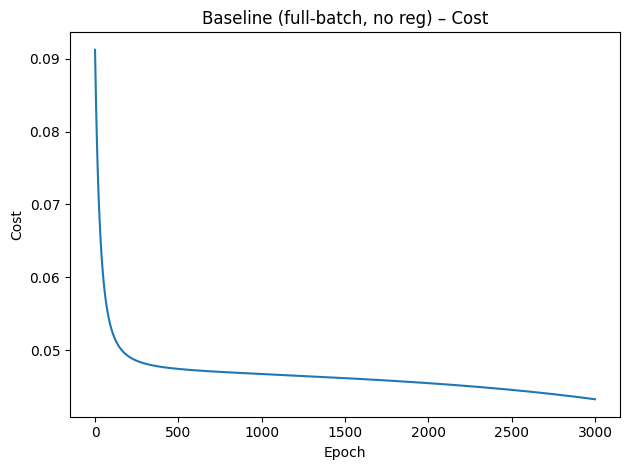

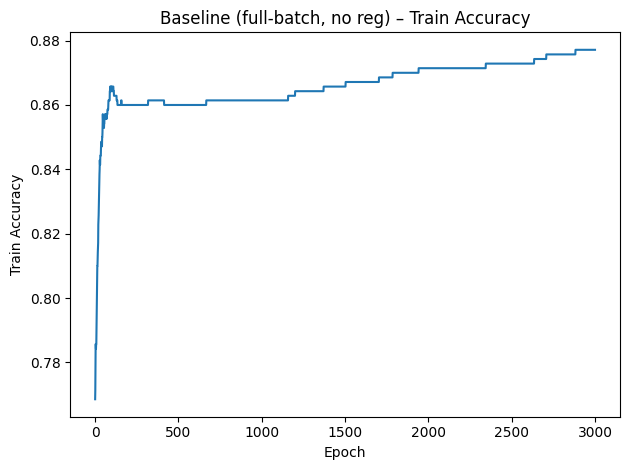

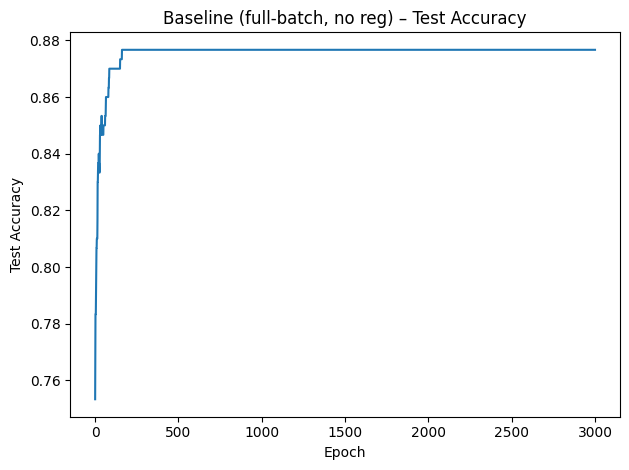

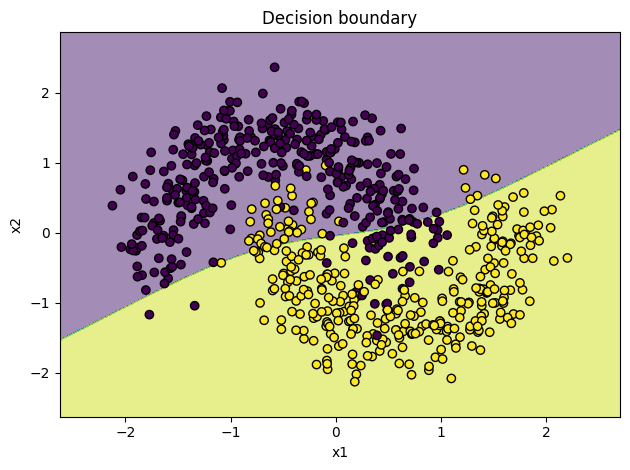

In [5]:

res_base = train_eval(
    rng_seed=42,
    n_epochs=3000,
    lr=0.05,
    batch_size=None,
    l2_lambda=0.0,
    keep_probs=None,
    use_dropout=False,
    layer_sizes=[2,16,16,1],
    act_kind="tanh",
    init_kind="xavier",
)
plot_history(res_base["history"], title_prefix="Baseline (full-batch, no reg)")

# Frontera de decisión
X_tr, X_te, y_tr, y_te = build_dataset()
def f_decision_base(Xin: Array) -> Array:
    acts, _ = make_acts([2,16,16,1], "tanh")
    A_out, _ = forward_propagation(Xin, res_base["params"], acts, keep_probs=None, training=False)
    return predict(A_out)
plot_decision_boundary(f_decision_base, X_tr, y_tr)



## Experimento 2 — Mini-batch sweep

**Qué estudiamos.** Efecto del tamaño de batch en la convergencia/ruido del coste y accuracy.

**Configuraciones** (mismo resto que baseline):  
`batch_size ∈ {256, 128, 64, 32, 16}`, `n_epochs=3000`, `lr=0.05`.

**Qué esperamos.**  
Batches pequeños ⇒ coste más ruidoso; convergencia por época comparable; accuracy final similar si no hay regularización fuerte.


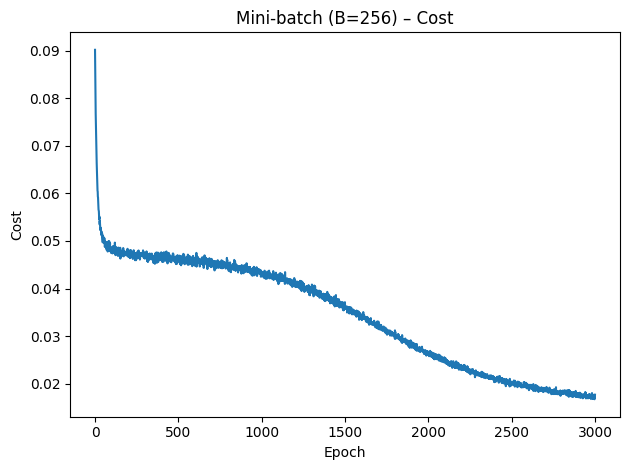

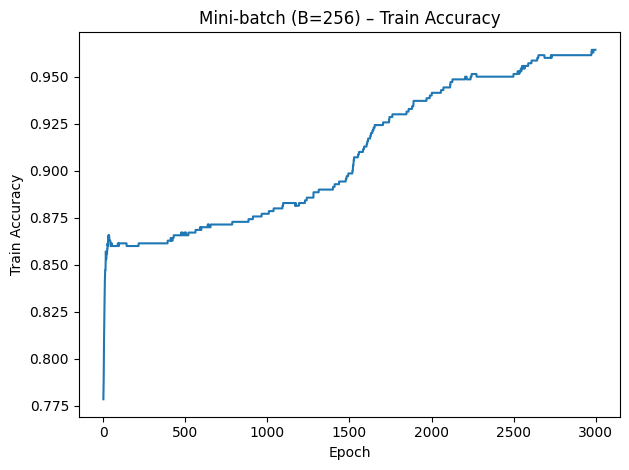

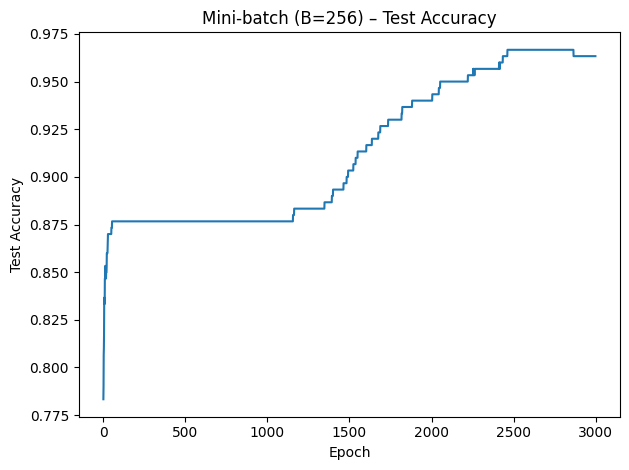

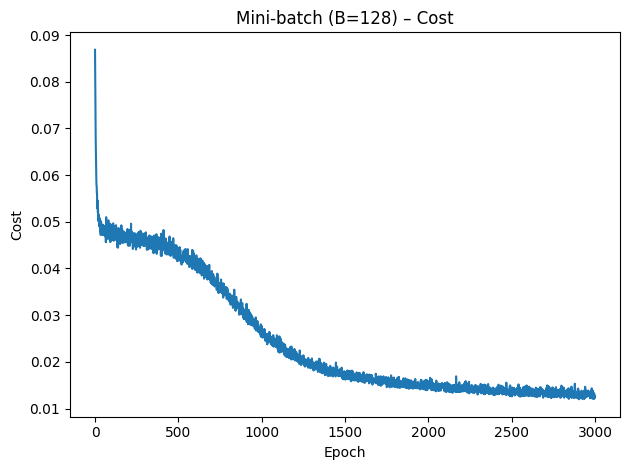

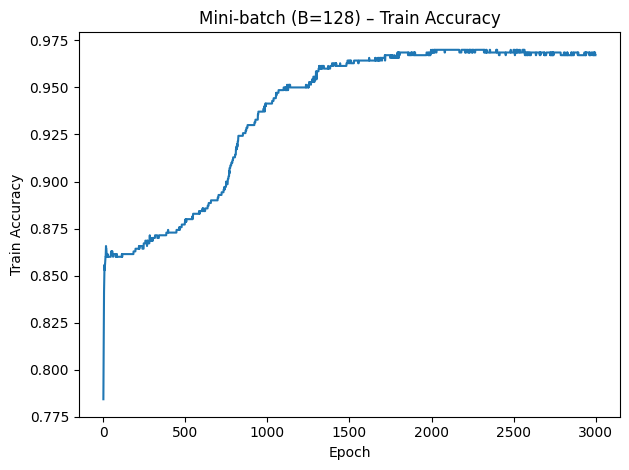

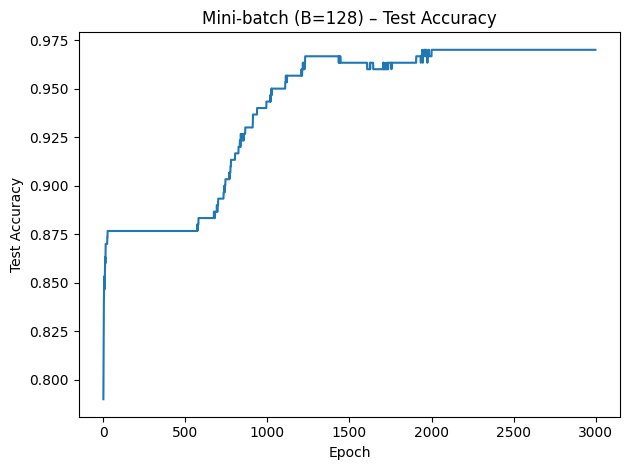

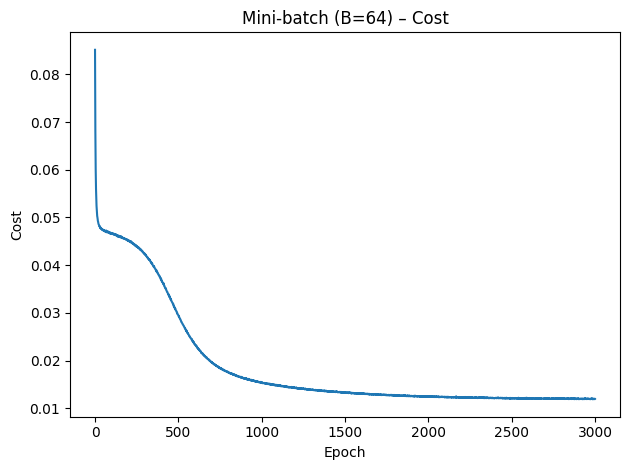

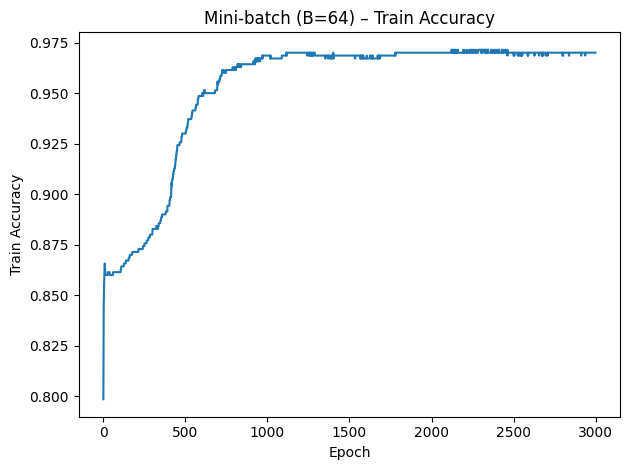

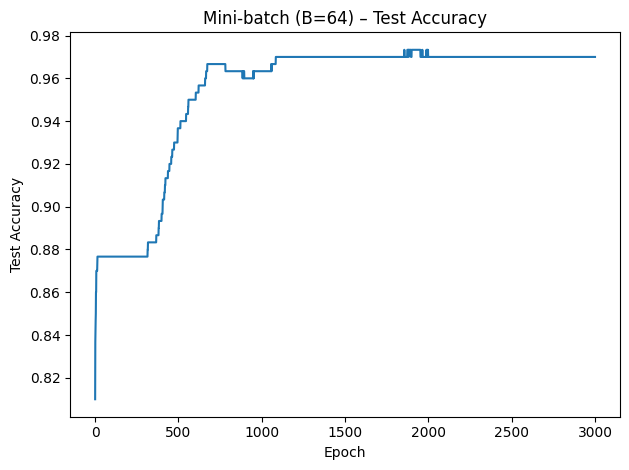

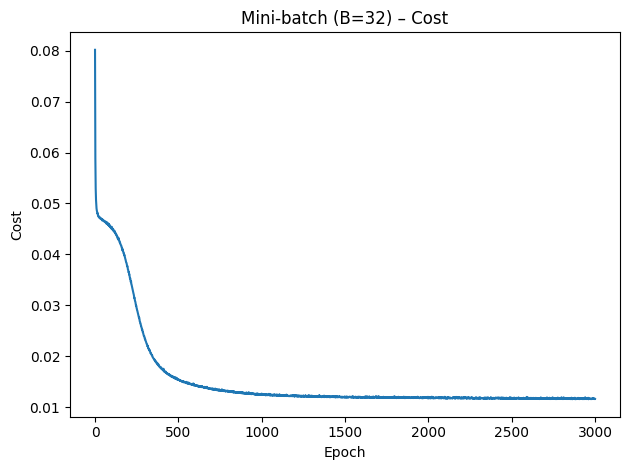

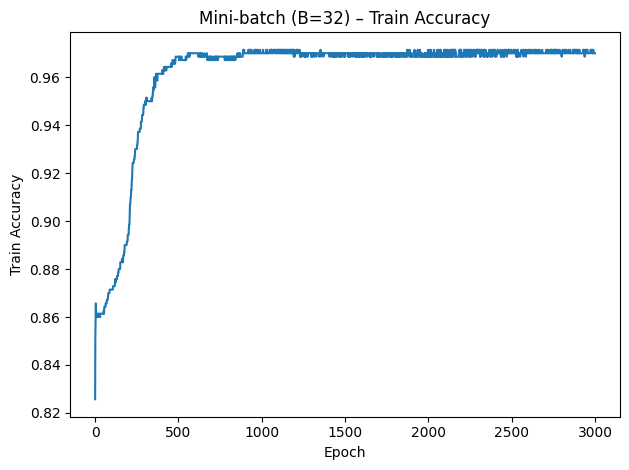

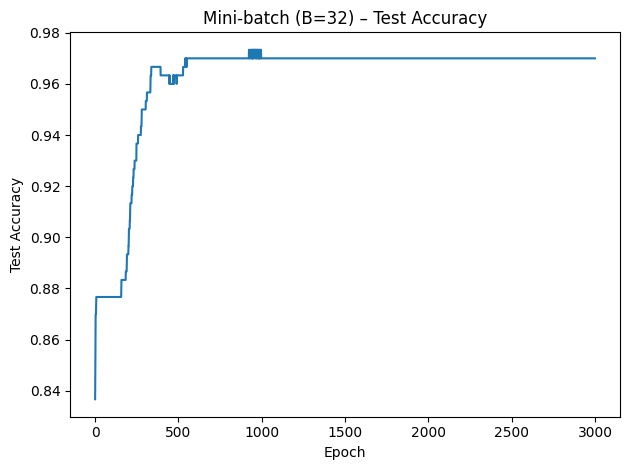

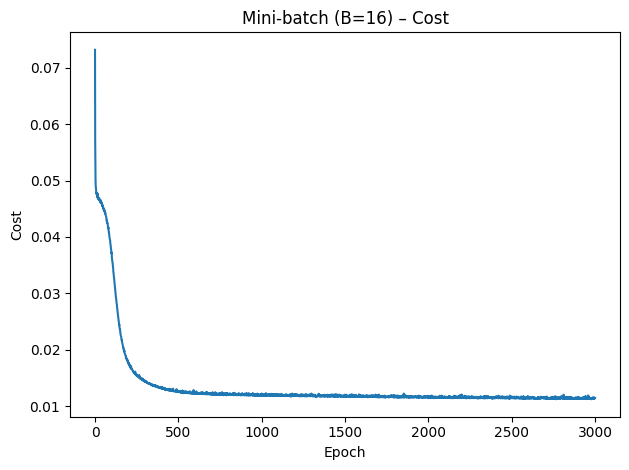

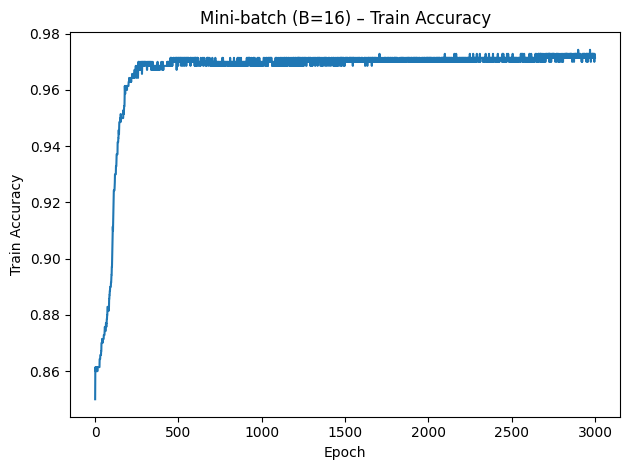

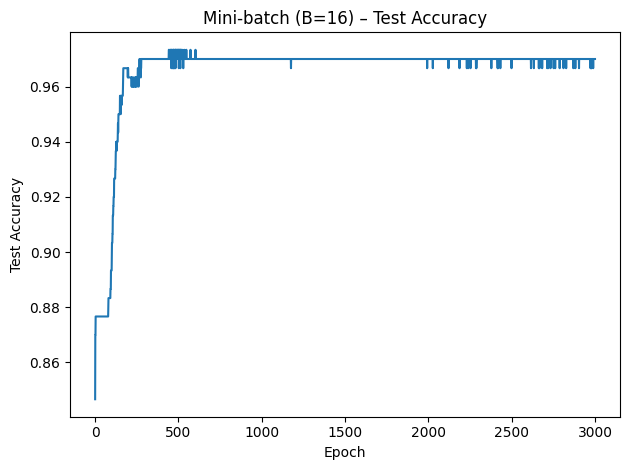

In [6]:

batch_grid = [256, 128, 64, 32, 16]
mini_results = {}
for b in batch_grid:
    res = train_eval(
        rng_seed=42, n_epochs=3000, lr=0.05,
        batch_size=b, l2_lambda=0.0,
        keep_probs=None, use_dropout=False,
        layer_sizes=[2,16,16,1], act_kind="tanh", init_kind="xavier"
    )
    mini_results[b] = res

for b in batch_grid:
    plot_history(mini_results[b]["history"], title_prefix=f"Mini-batch (B={b})")



## Experimento 3 — L2 (weight decay) grid

**Qué estudiamos.** Controlar la complejidad y el *gap* de generalización con L2.

**Configuraciones**: `l2_lambda ∈ {0, 1e-5, 1e-4, 1e-3, 1e-2}`,  
`batch_size=64`, `n_epochs=3000`, `lr=0.05`, sin dropout.

**Qué esperamos.**  
Mayor \(\lambda\) ⇒ menor \(\|W\|\), menor *gap*; demasiado grande ⇒ *underfit*.


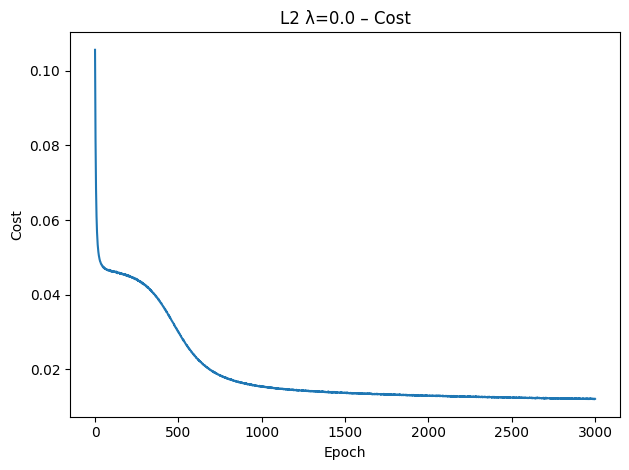

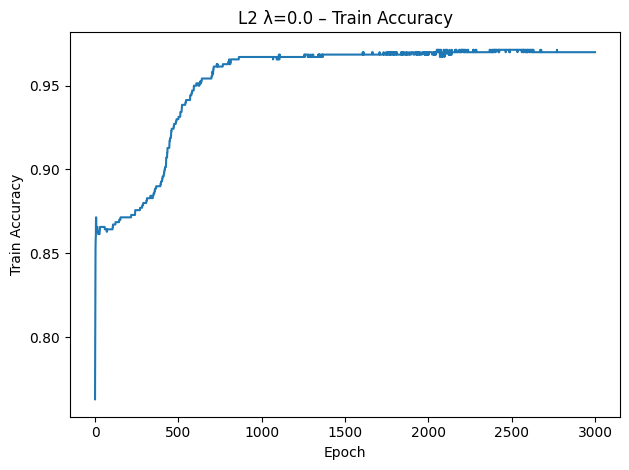

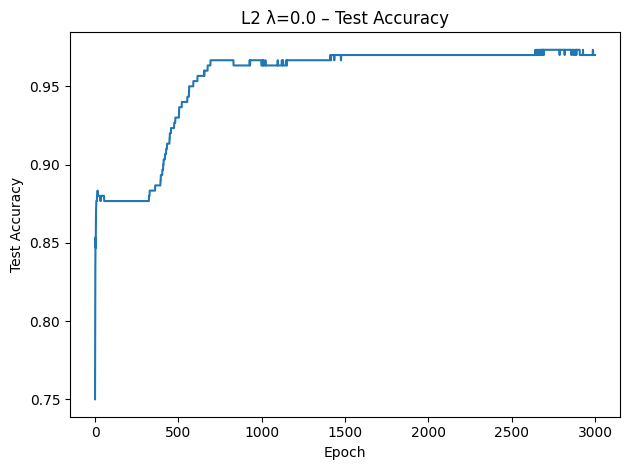

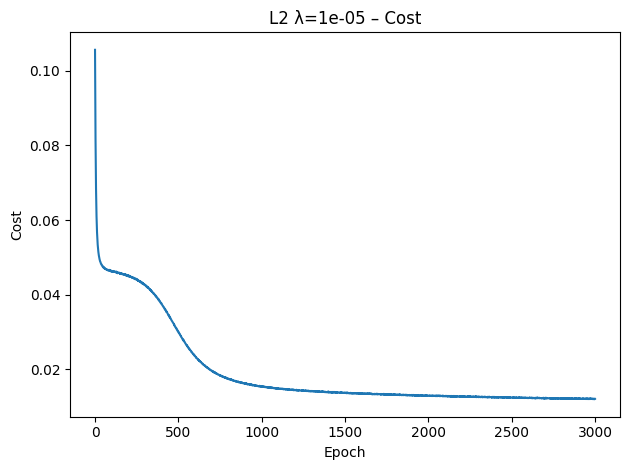

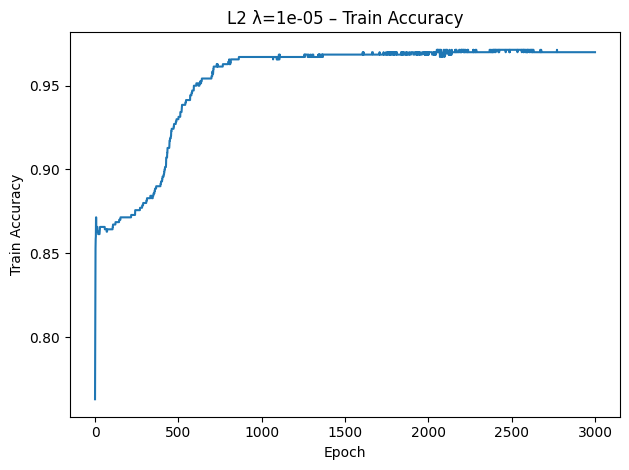

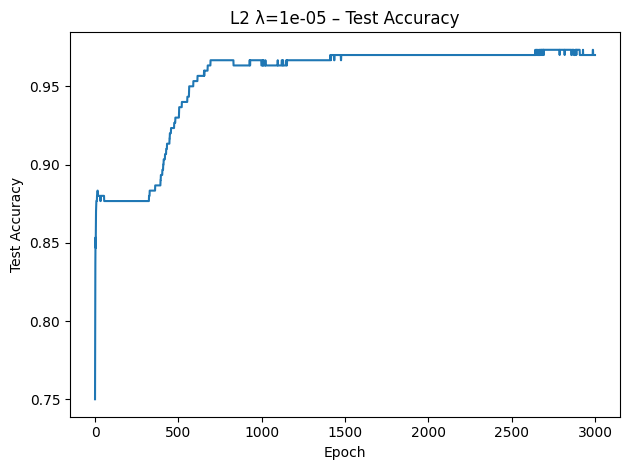

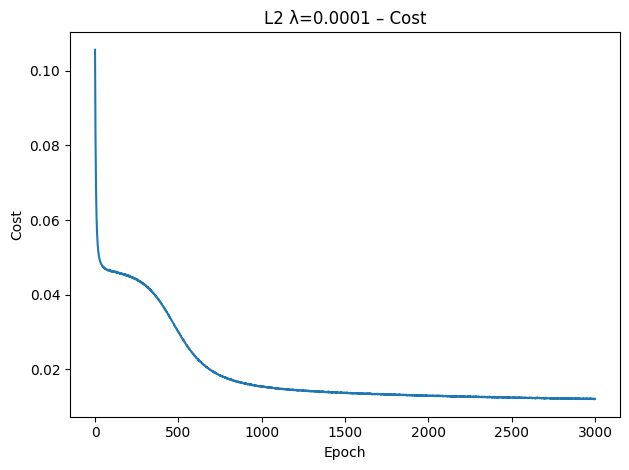

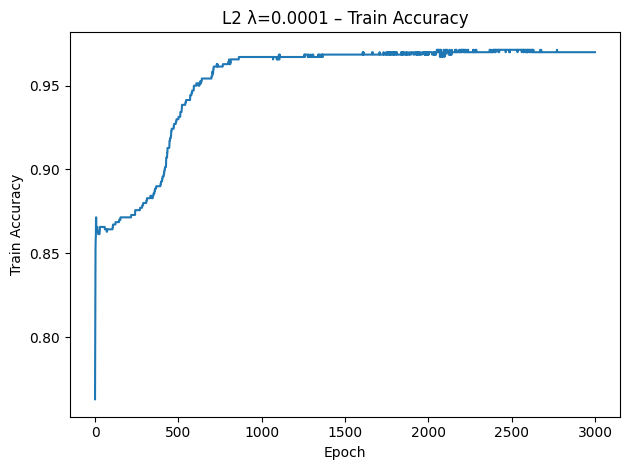

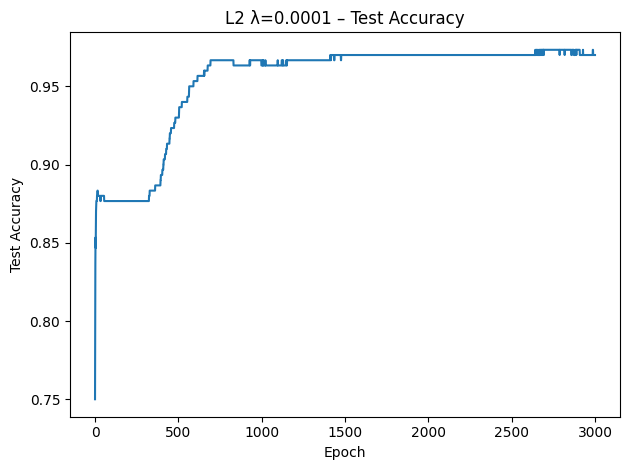

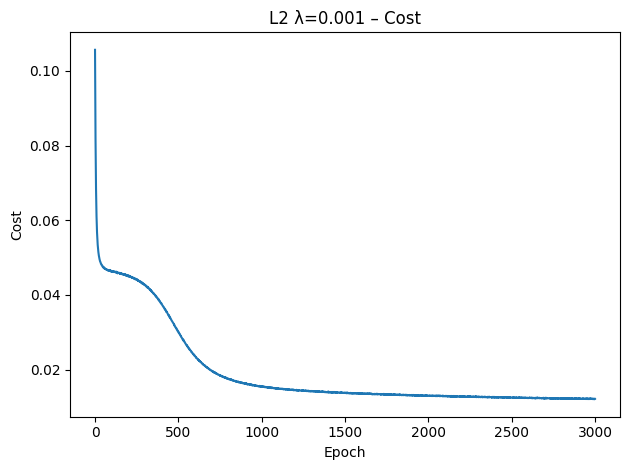

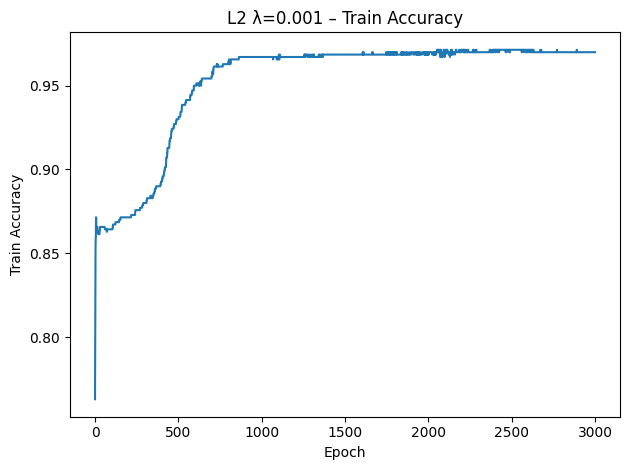

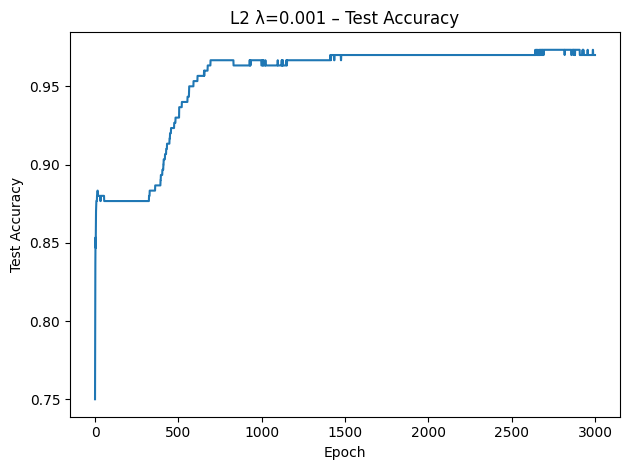

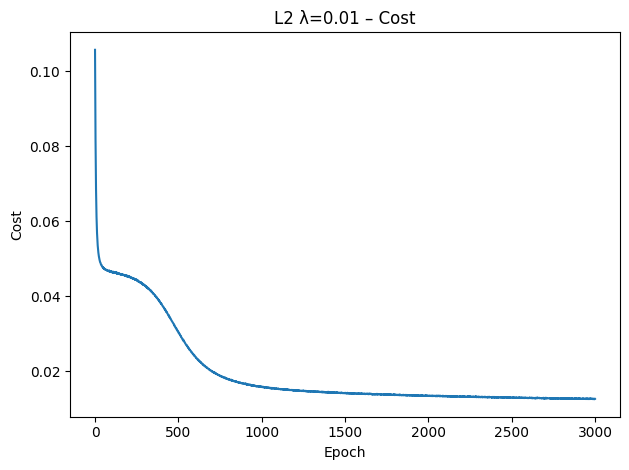

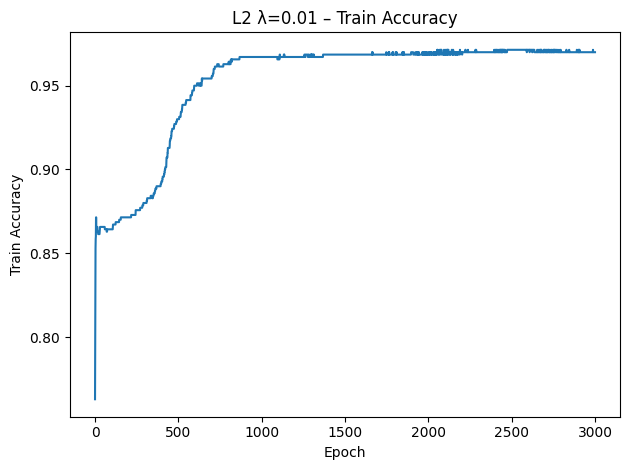

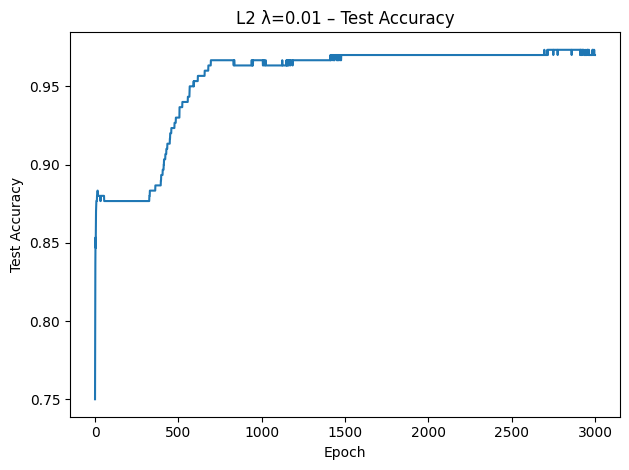

In [7]:

l2_grid = [0.0, 1e-5, 1e-4, 1e-3, 1e-2]
l2_results = {}
for lam in l2_grid:
    res = train_eval(
        rng_seed=123, n_epochs=3000, lr=0.05,
        batch_size=64, l2_lambda=lam,
        keep_probs=None, use_dropout=False,
        layer_sizes=[2,16,16,1], act_kind="tanh", init_kind="xavier"
    )
    l2_results[lam] = res

for lam in l2_grid:
    plot_history(l2_results[lam]["history"], title_prefix=f"L2 λ={lam}")



## Experimento 4 — Dropout (inverted) grid

**Qué estudiamos.** Efecto del dropout por capa oculta.

**Configuraciones**:  
- `{1:0.9, 2:0.9}`  
- `{1:0.8, 2:0.8}`  
- `{1:0.7, 2:0.7}`  
con `batch_size=64`, `l2_lambda=0`, `n_epochs=3000`, `lr=0.05`.

**Qué esperamos.**  
Más dropout (p menor) ⇒ mayor regularización y posible ralentización; demasiado fuerte ⇒ *underfit*.


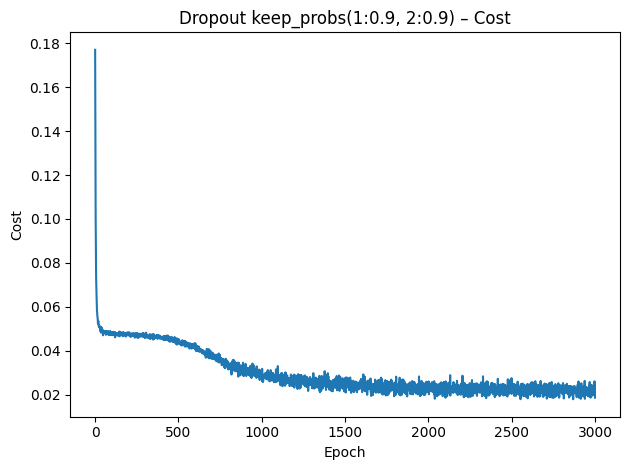

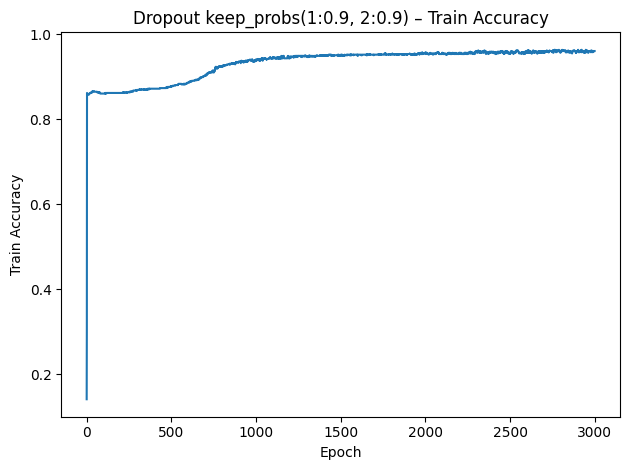

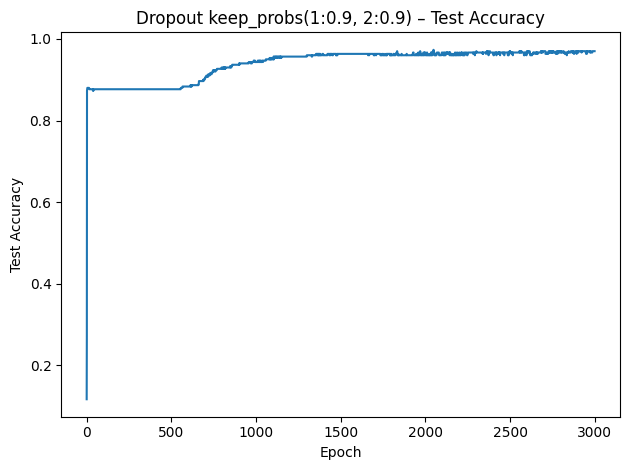

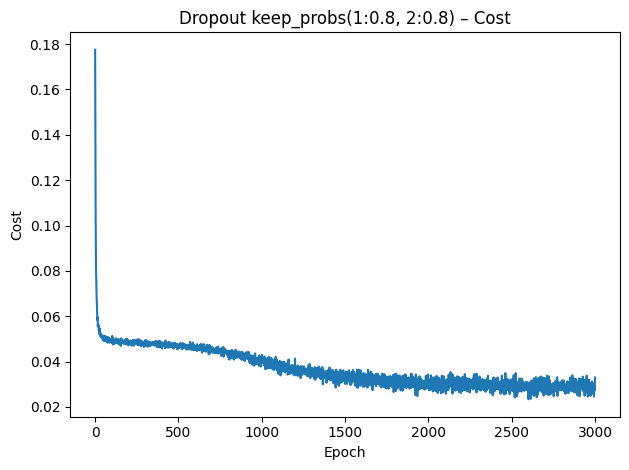

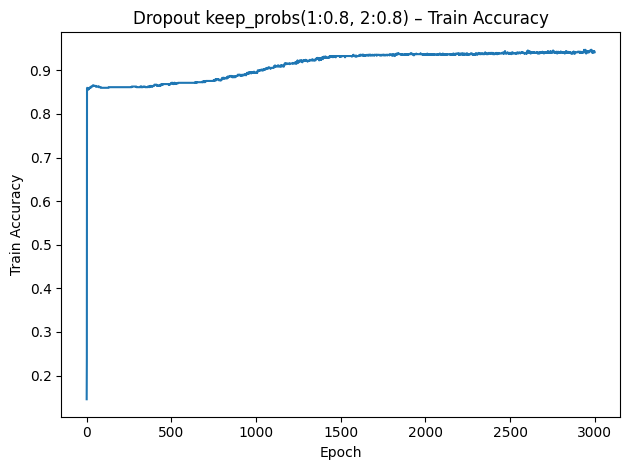

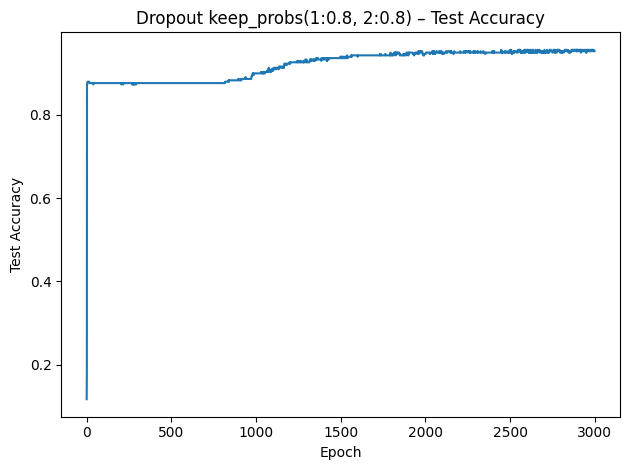

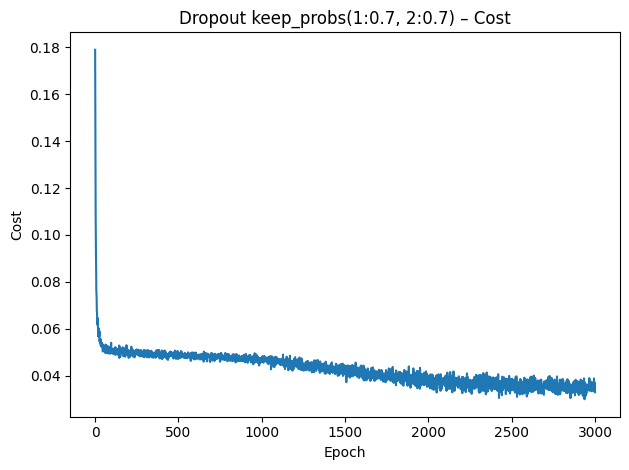

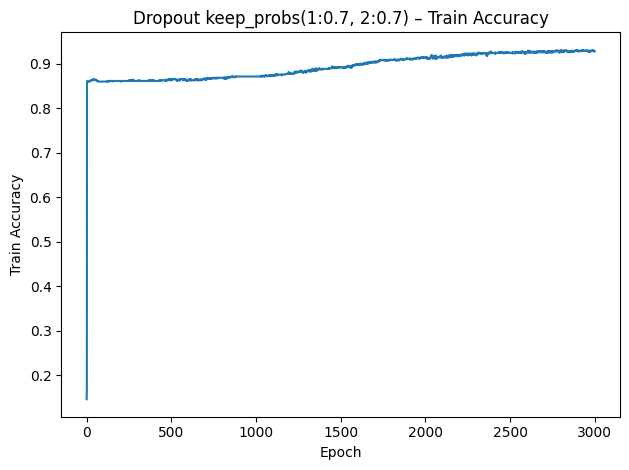

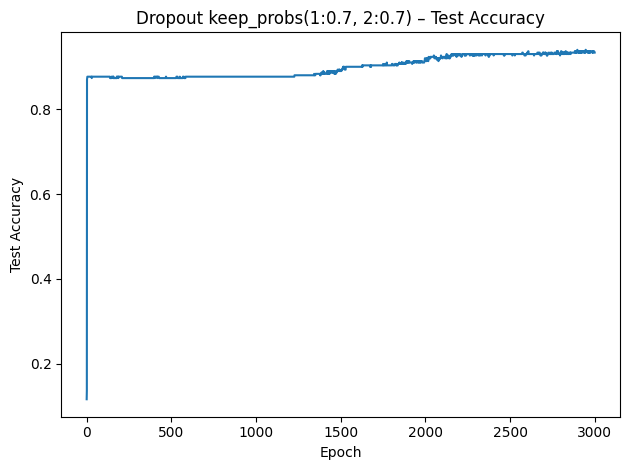

In [8]:

keep_sets = [{1:0.9,2:0.9}, {1:0.8,2:0.8}, {1:0.7,2:0.7}]
drop_results = {}
for kp in keep_sets:
    res = train_eval(
        rng_seed=777, n_epochs=3000, lr=0.05,
        batch_size=64, l2_lambda=0.0,
        keep_probs=kp, use_dropout=True,
        layer_sizes=[2,16,16,1], act_kind="tanh", init_kind="xavier"
    )
    drop_results[tuple(sorted(kp.items()))] = res

for kp in keep_sets:
    tag = ", ".join([f"{l}:{p}" for l,p in kp.items()])
    plot_history(drop_results[tuple(sorted(kp.items()))]["history"], title_prefix=f"Dropout keep_probs({tag})")



## Experimento 5 — Ablación: L2 vs Dropout vs Ambos

**Qué estudiamos.** Interacción entre regularizadores.

**Configuraciones** (resto baseline con `batch_size=64`):
1. **L2 only**: `l2_lambda=1e-3`, `use_dropout=False`.
2. **Dropout only**: `keep_probs={1:0.9,2:0.9}`, `l2_lambda=0`.
3. **Ambos**: `l2_lambda=1e-3`, `keep_probs={1:0.9,2:0.9}`.

**Qué esperamos.**  
La combinación suele estabilizar y reducir *gap* sin deteriorar en exceso la capacidad.


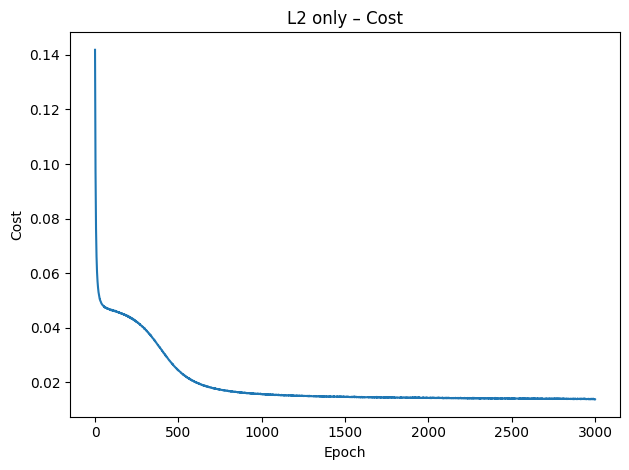

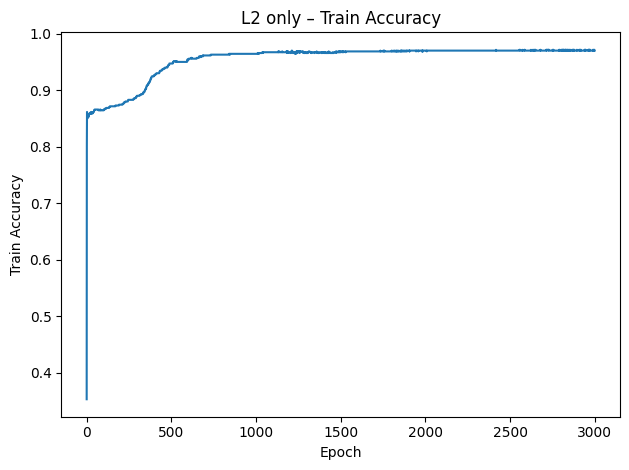

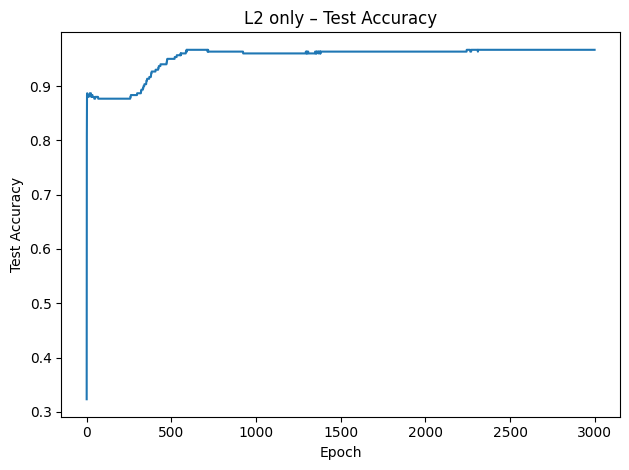

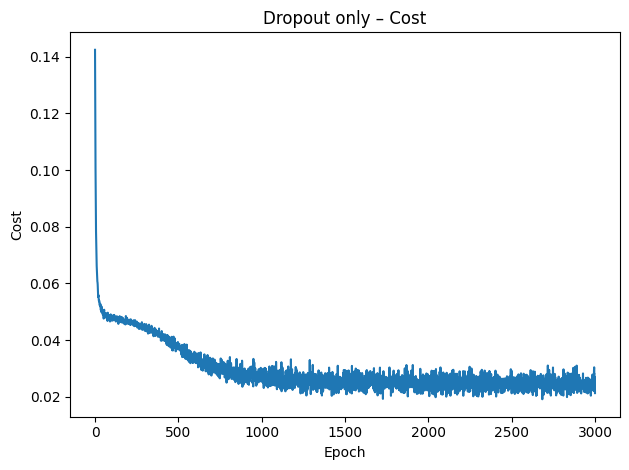

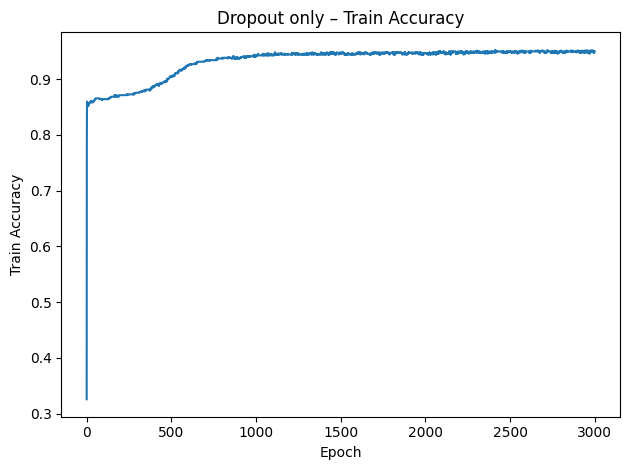

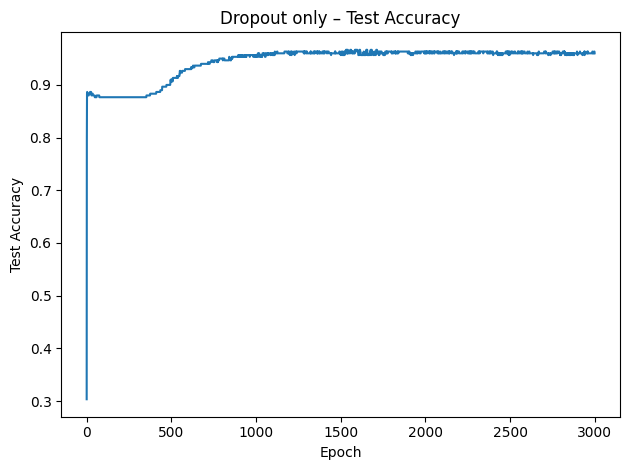

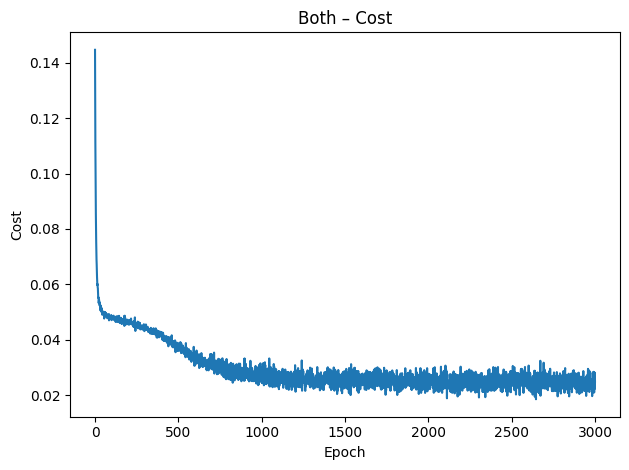

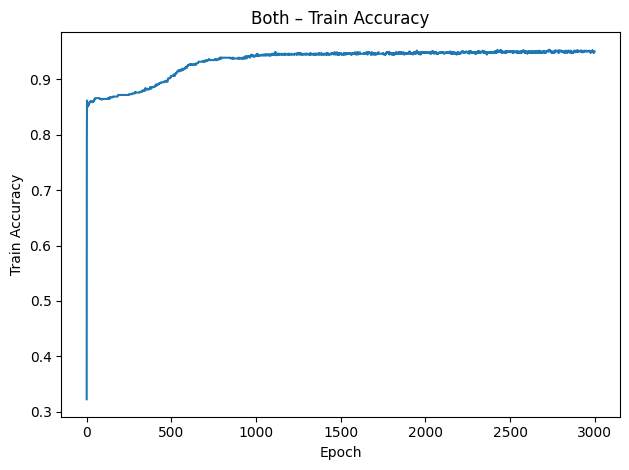

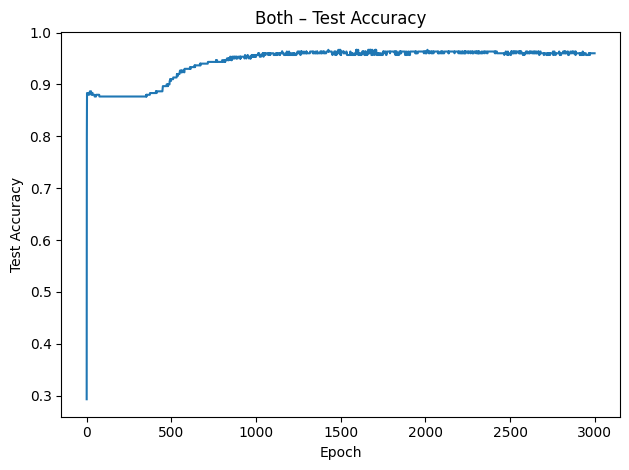

In [9]:

abl_configs = {
    "L2 only": dict(l2_lambda=1e-3, keep_probs=None, use_dropout=False),
    "Dropout only": dict(l2_lambda=0.0, keep_probs={1:0.9,2:0.9}, use_dropout=True),
    "Both": dict(l2_lambda=1e-3, keep_probs={1:0.9,2:0.9}, use_dropout=True),
}
abl_results = {}
for name, cfg in abl_configs.items():
    res = train_eval(
        rng_seed=2025, n_epochs=3000, lr=0.05,
        batch_size=64,
        l2_lambda=cfg["l2_lambda"],
        keep_probs=cfg["keep_probs"],
        use_dropout=cfg["use_dropout"],
        layer_sizes=[2,16,16,1], act_kind="tanh", init_kind="xavier"
    )
    abl_results[name] = res
    plot_history(res["history"], title_prefix=name)



## Experimento 6 — Fronteras de decisión comparadas

**Qué estudiamos.** Cómo cambian las fronteras con regularización y mini-batch.

**Configuraciones**: tomamos un caso representativo de cada experimento previo y graficamos.


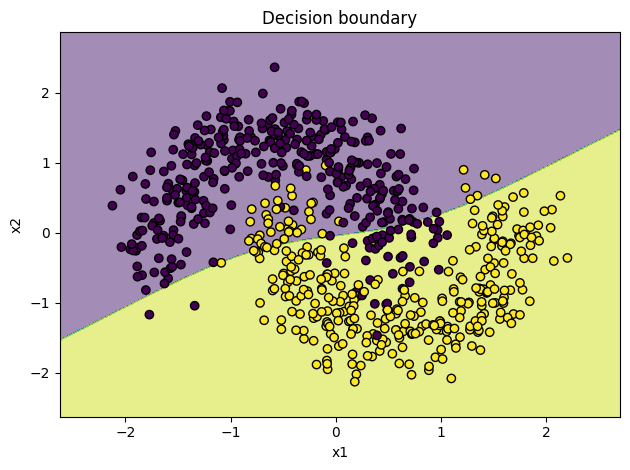

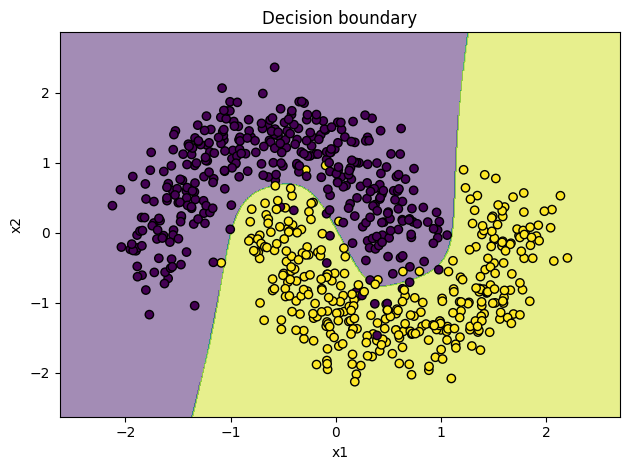

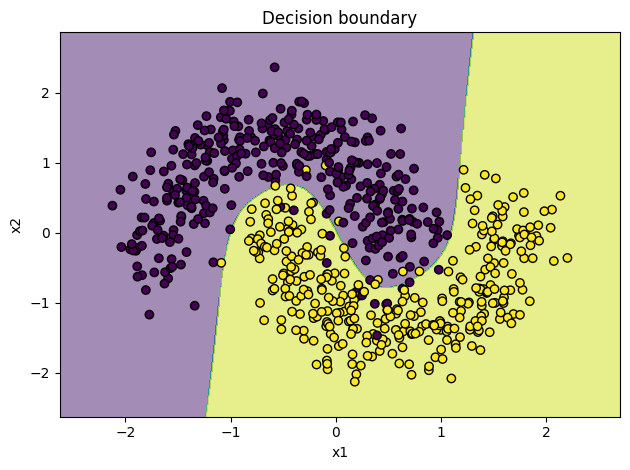

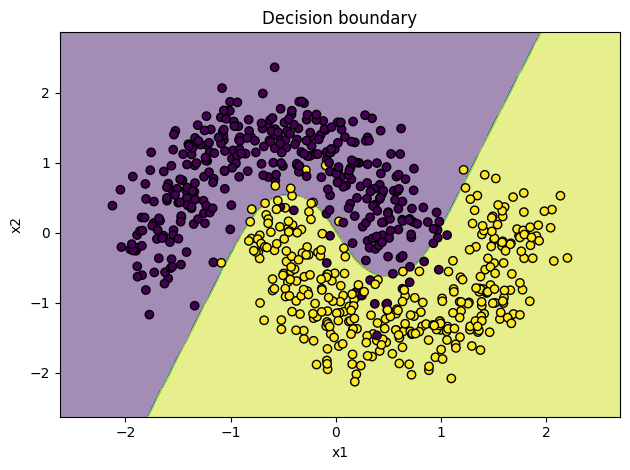

In [10]:

X_tr, X_te, y_tr, y_te = build_dataset()

def make_f_decision(params, layer_sizes, act_kind="tanh"):
    def _f(Xin: Array) -> Array:
        acts, _ = make_acts(layer_sizes, act_kind)
        A_out, _ = forward_propagation(Xin, params, acts, keep_probs=None, training=False)
        return predict(A_out)
    return _f

# Selecciones
f_base = make_f_decision(res_base["params"], [2,16,16,1], "tanh")
plot_decision_boundary(f_base, X_tr, y_tr)

if 32 in mini_results:
    f_mb32 = make_f_decision(mini_results[32]["params"], [2,16,16,1], "tanh")
    plot_decision_boundary(f_mb32, X_tr, y_tr)

if 1e-3 in l2_results:
    f_l2 = make_f_decision(l2_results[1e-3]["params"], [2,16,16,1], "tanh")
    plot_decision_boundary(f_l2, X_tr, y_tr)

kp_key = tuple(sorted({1:0.9,2:0.9}.items()))
if kp_key in drop_results:
    f_do = make_f_decision(drop_results[kp_key]["params"], [2,16,16,1], "tanh")
    plot_decision_boundary(f_do, X_tr, y_tr)



### Notas finales y próximos pasos (Parte 2)
- **Activaciones/Inicializaciones**: comparar `relu+he` vs `tanh+xavier` con trazas de varianzas de \(Z^{[l]}\).
- **Diagnósticos**: normas de gradiente por capa, histogramas de activaciones, *ReLUs muertas*.
- **Seeds y varianza**: N réplicas y dispersión de `acc_te`.
- **Tests numéricos**: verificación de gradiente por diferencias finitas.

Si lo deseas, preparo una **Parte 2** con estas secciones y utilidades adicionales (medidas de norma, histogramas y tests).
